This notebook contains code to generate parameter fits and predicted Q-values for the HMM model

There are two included models:
1. Turn Bias
2. Spatial Bias

The likelihood function is as follows:


Assuming we're at stem 1,
```
QEff1 = βstay * Q(OppositeLeaf) + stay_bias
QEff2 = βgo * QAvg(stem) + spatial_bias[2]
QEff3 = βgo * QAvg(stem)
```
Our stem choice is then predicted by a softmax: $p(a) = \frac{\exp{p(a)}}{\sum_{a'}\exp{p(a')}}$

In the Turn Bias model, all spatial biases are modeled by a single `turn_bias` parameter
In the Spatial Bias model, each stem has a unique spatial bias


In [1]:
# Whether to recompute results
RERUN = false;

In [2]:
# Save Q-values and other meta-information
SAVE_Q = true;

In [3]:
using SpecialFunctions
using Plots
using StatsPlots
using FileIO
using EM
filepath = ".."
include("$(filepath)/code/qlearner.jl")
include("$(filepath)/code/util.jl")
include("$(filepath)/code/em_scripts.jl");

# Turn Bias

In [4]:
function find_Q_vals_by_day(animal, results; add_leaf=true, rewscaled=true)
    data = load_animal(animal, "..")
    ndays = maximum(data.daynum)
    liks = zeros(ndays)
    dfs = []
    for i in 1:ndays
        (liks[i], df) = qlik(view(data, data.daynum .== i, :), results;
            subject=i, add_leaf=add_leaf, rewscaled=rewscaled, record=true)
        push!(dfs, df)
    end
    # Combine all session results
    record_df = vcat(dfs...)
    # Append columns to the original data
    hcat(data, record_df)
end;

In [5]:
results = Dict()
Qs = Dict();

# Model Fits

In [6]:
fn = run_q_leaf_initialQ_stay_turn_leafspatial_γ2
fnname = "leaf_initialQ_stay_turn_leafspatial_γ2_rewscaled"
println("Model: $(fn)")

Model: run_q_leaf_initialQ_stay_turn_leafspatial_γ2


In [7]:
animal = "peanut"
if RERUN
    results[animal] = fn(load_animal(animal); maxiter=100, extended=true)
    Qs[animal] = find_Q_vals_by_day(animal, results[animal])    
    save("$(filepath)/results/q_biases/q_$(fnname)_$(animal).jld2", "results", results[animal])
else
    results[animal] = load("$(filepath)/results/q_biases/q_$(fnname)_$(animal).jld2", "q_$(fnname)_$(animal)")
    Qs[animal] = find_Q_vals_by_day(animal, results[animal])
end
if SAVE_Q
    CSV.write("$(filepath)/results/qlearner_q_vals/qlearner_q_vals_$(fnname)_$(animal).csv", Qs[animal])
end
println("Turn Bias: $(animal)")
println("AIC: $(round(iaic(results[animal]); digits=2))")
transforms = [["volatility", x->0.5+0.5*erf(x / sqrt(2))]]
HTML(show_results(results[animal], transforms=transforms))

Turn Bias: peanut
AIC: 3453.82


HTML{String}("<pre>[\"βgo\", \"βstay\", \"βleaf\", \"stay_bias\", \"turn_bias\", \"leaf_spatial_1\", \"leaf_spatial_2\", \"leaf_spatial_3\", \"γ2\", \"initial_Q\", \"α\"]<br/></pre>β:<br/><pre> βgo   βstay βleaf stay_ turn_b leaf leaf_ leaf_ γ2     initi α     <br/> 1.51  2.98  1.07  3.17  <span style='color: red'>-0.77</span>  0.1  0.07  0.21  <span style='color: red'>-0.82</span>  1.37  <span style='color: red'>-0.1</span><br/>p:<br/> 0.01  0.01  0.01  0.01  0.02  0.9  0.97  0.91  0.01  0.04  0.59</pre>σ²:<br/><pre>  0.75   0.28  <span style='color: red'>-0.78</span>  <span style='color: red'>-0.1</span>   <span style='color: red'>-0.43</span>   0.78   2.14   2.1    0.21   1.35   0.2<br/>  0.28   0.3   <span style='color: red'>-0.13</span>   0.03  <span style='color: red'>-0.43</span>   0.03   0.36   0.12   0.08   0.07   0.01<br/> <span style='color: red'>-0.78</span>  <span style='color: red'>-0.13</span>   1.07   0.13   0.16  <span style='color: red'>-1.44</span>  <span style='color: red'>-3.0</span>   <span style='color: red'>-3.39</span>  <span style='color: red'>-0.21</span>  <span style='color: red'>-1.94</span>  <span style='color: red'>-0.28</span><br/> <span style='color: red'>-0.1</span>    0.03   0.13   0.11   0.01  <span style='color: red'>-0.13</span>  <span style='color: red'>-0.5</span>   <span style='color: red'>-0.57</span>   0.03  <span style='color: red'>-0.08</span>   0.03<br/> <span style='color: red'>-0.43</span>  <span style='color: red'>-0.43</span>   0.16   0.01   0.68   0.2   <span style='color: red'>-0.16</span>   0.25  <span style='color: red'>-0.13</span>  <span style='color: red'>-0.08</span>  <span style='color: red'>-0.05</span><br/>  0.78   0.03  <span style='color: red'>-1.44</span>  <span style='color: red'>-0.13</span>   0.2    3.0    5.92   6.88  <span style='color: red'>-0.04</span>   2.01  <span style='color: red'>-0.05</span><br/>  2.14   0.36  <span style='color: red'>-3.0</span>   <span style='color: red'>-0.5</span>   <span style='color: red'>-0.16</span>   5.92  14.77  15.68  <span style='color: red'>-0.24</span>   3.39  <span style='color: red'>-0.64</span><br/>  2.1    0.12  <span style='color: red'>-3.39</span>  <span style='color: red'>-0.57</span>   0.25   6.88  15.68  17.39  <span style='color: red'>-0.27</span>   4.1   <span style='color: red'>-0.53</span><br/>  0.21   0.08  <span style='color: red'>-0.21</span>   0.03  <span style='color: red'>-0.13</span>  <span style='color: red'>-0.04</span>  <span style='color: red'>-0.24</span>  <span style='color: red'>-0.27</span>   0.2    0.76   0.27<br/>  1.35   0.07  <span style='color: red'>-1.94</span>  <span style='color: red'>-0.08</span>  <span style='color: red'>-0.08</span>   2.01   3.39   4.1    0.76   4.71   1.08<br/>  0.2    0.01  <span style='color: red'>-0.28</span>   0.03  <span style='color: red'>-0.05</span>  <span style='color: red'>-0.05</span>  <span style='color: red'>-0.64</span>  <span style='color: red'>-0.53</span>   0.27   1.08   0.42</pre>")

In [8]:
animal = "senor"
if RERUN
    results[animal] = fn(load_animal(animal); maxiter=100, extended=true)
    Qs[animal] = find_Q_vals_by_day(animal, results[animal])    
    save("$(filepath)/results/q_biases/q_$(fnname)_$(animal).jld2", "results", results[animal])
else
    results[animal] = load("$(filepath)/results/q_biases/q_$(fnname)_$(animal).jld2", "q_$(fnname)_$(animal)")
    Qs[animal] = find_Q_vals_by_day(animal, results[animal])
end
if SAVE_Q
    CSV.write("$(filepath)/results/qlearner_q_vals/qlearner_q_vals_$(fnname)_$(animal).csv", Qs[animal])
end
println("Turn Bias: $(animal)")
println("AIC: $(round(iaic(results[animal]); digits=2))")
transforms = [["volatility", x->0.5+0.5*erf(x / sqrt(2))]]
HTML(show_results(results[animal], transforms=transforms))

Turn Bias: senor
AIC: 3172.22


HTML{String}("<pre>[\"βgo\", \"βstay\", \"βleaf\", \"stay_bias\", \"turn_bias\", \"leaf_spatial_1\", \"leaf_spatial_2\", \"leaf_spatial_3\", \"γ2\", \"initial_Q\", \"α\"]<br/></pre>β:<br/><pre> βgo   βsta βlea stay_ turn_b leaf_s leaf_s leaf_ γ2     initi α     <br/> 1.67  2.8  0.9  3.91  <span style='color: red'>-0.24</span>  <span style='color: red'>-1.04</span>  <span style='color: red'>-2.85</span>  1.27  <span style='color: red'>-0.59</span>  2.54  0.01<br/>p:<br/> 0.01  0.01  0.01  0.01  0.47  0.21  0.01  0.01  0.01  0.08  0.95</pre>σ²:<br/><pre>  0.81   0.19   0.11  <span style='color: red'>-0.09</span>  <span style='color: red'>-0.33</span>  <span style='color: red'>-0.12</span>  <span style='color: red'>-0.23</span>   0.16  <span style='color: red'>-0.12</span>   0.94  <span style='color: red'>-0.03</span><br/>  0.19   0.39   0.23  <span style='color: red'>-0.03</span>  <span style='color: red'>-0.33</span>  <span style='color: red'>-0.77</span>  <span style='color: red'>-0.24</span>  <span style='color: red'>-0.12</span>   0.15   0.1    0.01<br/>  0.11   0.23   0.55   0.13  <span style='color: red'>-0.12</span>   0.11  <span style='color: red'>-1.45</span>   0.84   0.1   <span style='color: red'>-0.08</span>  <span style='color: red'>-0.02</span><br/> <span style='color: red'>-0.09</span>  <span style='color: red'>-0.03</span>   0.13   0.17   0.32   0.87   0.15   0.41  <span style='color: red'>-0.04</span>  <span style='color: red'>-0.37</span>  <span style='color: red'>-0.12</span><br/> <span style='color: red'>-0.33</span>  <span style='color: red'>-0.33</span>  <span style='color: red'>-0.12</span>   0.32   1.04   2.18   1.07   0.5   <span style='color: red'>-0.23</span>  <span style='color: red'>-0.77</span>  <span style='color: red'>-0.26</span><br/> <span style='color: red'>-0.12</span>  <span style='color: red'>-0.77</span>   0.11   0.87   2.18   6.85   3.61   2.34  <span style='color: red'>-0.73</span>  <span style='color: red'>-1.82</span>  <span style='color: red'>-0.89</span><br/> <span style='color: red'>-0.23</span>  <span style='color: red'>-0.24</span>  <span style='color: red'>-1.45</span>   0.15   1.07   3.61  11.75  <span style='color: red'>-2.09</span>  <span style='color: red'>-0.44</span>  <span style='color: red'>-2.2</span>   <span style='color: red'>-0.91</span><br/>  0.16  <span style='color: red'>-0.12</span>   0.84   0.41   0.5    2.34  <span style='color: red'>-2.09</span>   2.43  <span style='color: red'>-0.19</span>  <span style='color: red'>-0.28</span>  <span style='color: red'>-0.2</span><br/> <span style='color: red'>-0.12</span>   0.15   0.1   <span style='color: red'>-0.04</span>  <span style='color: red'>-0.23</span>  <span style='color: red'>-0.73</span>  <span style='color: red'>-0.44</span>  <span style='color: red'>-0.19</span>   0.16  <span style='color: red'>-0.09</span>   0.08<br/>  0.94   0.1   <span style='color: red'>-0.08</span>  <span style='color: red'>-0.37</span>  <span style='color: red'>-0.77</span>  <span style='color: red'>-1.82</span>  <span style='color: red'>-2.2</span>   <span style='color: red'>-0.28</span>  <span style='color: red'>-0.09</span>   2.03   0.32<br/> <span style='color: red'>-0.03</span>   0.01  <span style='color: red'>-0.02</span>  <span style='color: red'>-0.12</span>  <span style='color: red'>-0.26</span>  <span style='color: red'>-0.89</span>  <span style='color: red'>-0.91</span>  <span style='color: red'>-0.2</span>    0.08   0.32   0.16</pre>")

In [9]:
animal = "chimi"
if RERUN
    results[animal] = fn(load_animal(animal); maxiter=100, extended=true)
    Qs[animal] = find_Q_vals_by_day(animal, results[animal])    
    save("$(filepath)/results/q_biases/q_$(fnname)_$(animal).jld2", "results", results[animal])
else
    results[animal] = load("$(filepath)/results/q_biases/q_$(fnname)_$(animal).jld2", "q_$(fnname)_$(animal)")
    Qs[animal] = find_Q_vals_by_day(animal, results[animal])
end
if SAVE_Q
    CSV.write("$(filepath)/results/qlearner_q_vals/qlearner_q_vals_$(fnname)_$(animal).csv", Qs[animal])
end
println("Turn Bias: $(animal)")
println("AIC: $(round(iaic(results[animal]); digits=2))")
transforms = [["volatility", x->0.5+0.5*erf(x / sqrt(2))]]
HTML(show_results(results[animal], transforms=transforms))

Turn Bias: chimi
AIC: 1957.36


HTML{String}("<pre>[\"βgo\", \"βstay\", \"βleaf\", \"stay_bias\", \"turn_bias\", \"leaf_spatial_1\", \"leaf_spatial_2\", \"leaf_spatial_3\", \"γ2\", \"initial_Q\", \"α\"]<br/></pre>β:<br/><pre> βgo   βstay βleaf stay_ turn_b leaf_s leaf_s leaf γ2     init α      <br/> 2.27  1.98  0.67  4.68  <span style='color: red'>-0.21</span>  <span style='color: red'>-0.22</span>  <span style='color: red'>-0.22</span>  1.0  <span style='color: red'>-0.27</span>  1.8  <span style='color: red'>-0.63</span><br/>p:<br/> 0.01  0.01  0.24  0.01  0.49  0.35  0.49  0.13  0.24  0.01  0.04</pre>σ²:<br/><pre>  1.34  <span style='color: red'>-0.96</span>   0.13   0.37  <span style='color: red'>-0.46</span>  <span style='color: red'>-0.15</span>  <span style='color: red'>-0.29</span>  <span style='color: red'>-0.23</span>   0.15   1.48   0.17<br/> <span style='color: red'>-0.96</span>   5.46  <span style='color: red'>-2.7</span>   <span style='color: red'>-2.3</span>    2.0    0.7    0.76  <span style='color: red'>-2.03</span>  <span style='color: red'>-0.6</span>   <span style='color: red'>-2.47</span>   0.91<br/>  0.13  <span style='color: red'>-2.7</span>    3.39   0.64  <span style='color: red'>-1.12</span>  <span style='color: red'>-1.57</span>  <span style='color: red'>-1.42</span>   3.57   0.09   1.84  <span style='color: red'>-0.33</span><br/>  0.37  <span style='color: red'>-2.3</span>    0.64   1.57  <span style='color: red'>-0.77</span>   0.4    0.1   <span style='color: red'>-0.6</span>    0.42   0.44  <span style='color: red'>-0.69</span><br/> <span style='color: red'>-0.46</span>   2.0   <span style='color: red'>-1.12</span>  <span style='color: red'>-0.77</span>   0.78   0.32   0.41  <span style='color: red'>-0.79</span>  <span style='color: red'>-0.21</span>  <span style='color: red'>-1.09</span>   0.28<br/> <span style='color: red'>-0.15</span>   0.7   <span style='color: red'>-1.57</span>   0.4    0.32   1.51   0.85  <span style='color: red'>-3.19</span>   0.15  <span style='color: red'>-1.29</span>  <span style='color: red'>-0.26</span><br/> <span style='color: red'>-0.29</span>   0.76  <span style='color: red'>-1.42</span>   0.1    0.41   0.85   0.83  <span style='color: red'>-1.65</span>   0.04  <span style='color: red'>-1.08</span>  <span style='color: red'>-0.1</span><br/> <span style='color: red'>-0.23</span>  <span style='color: red'>-2.03</span>   3.57  <span style='color: red'>-0.6</span>   <span style='color: red'>-0.79</span>  <span style='color: red'>-3.19</span>  <span style='color: red'>-1.65</span>   7.28  <span style='color: red'>-0.32</span>   2.34   0.3<br/>  0.15  <span style='color: red'>-0.6</span>    0.09   0.42  <span style='color: red'>-0.21</span>   0.15   0.04  <span style='color: red'>-0.32</span>   0.14   0.15  <span style='color: red'>-0.17</span><br/>  1.48  <span style='color: red'>-2.47</span>   1.84   0.44  <span style='color: red'>-1.09</span>  <span style='color: red'>-1.29</span>  <span style='color: red'>-1.08</span>   2.34   0.15   2.78   0.17<br/>  0.17   0.91  <span style='color: red'>-0.33</span>  <span style='color: red'>-0.69</span>   0.28  <span style='color: red'>-0.26</span>  <span style='color: red'>-0.1</span>    0.3   <span style='color: red'>-0.17</span>   0.17   0.4</pre>")

In [10]:
animal = "j16"
if RERUN
    results[animal] = fn(load_animal(animal); maxiter=100, extended=true)
    Qs[animal] = find_Q_vals_by_day(animal, results[animal])    
    save("$(filepath)/results/q_biases/q_$(fnname)_$(animal).jld2", "results", results[animal])
else
    results[animal] = load("$(filepath)/results/q_biases/q_$(fnname)_$(animal).jld2", "q_$(fnname)_$(animal)")
    Qs[animal] = find_Q_vals_by_day(animal, results[animal])
end
if SAVE_Q
    CSV.write("$(filepath)/results/qlearner_q_vals/qlearner_q_vals_$(fnname)_$(animal).csv", Qs[animal])
end
println("Turn Bias: $(animal)")
println("AIC: $(round(iaic(results[animal]); digits=2))")
transforms = [["volatility", x->0.5+0.5*erf(x / sqrt(2))]]
HTML(show_results(results[animal], transforms=transforms))

Turn Bias: j16
AIC: 2431.86


HTML{String}("<pre>[\"βgo\", \"βstay\", \"βleaf\", \"stay_bias\", \"turn_bias\", \"leaf_spatial_1\", \"leaf_spatial_2\", \"leaf_spatial_3\", \"γ2\", \"initial_Q\", \"α\"]<br/></pre>β:<br/><pre> βgo   βstay βleaf stay_ turn_b leaf_s leaf_s leaf γ2     initi α     <br/> 1.94  3.11  0.56  3.93  <span style='color: red'>-0.13</span>  <span style='color: red'>-0.59</span>  <span style='color: red'>-0.12</span>  0.5  <span style='color: red'>-0.46</span>  2.03  0.06<br/>p:<br/> 0.01  0.01  0.01  0.01  0.55  0.2  NaN  0.31  NaN  NaN  0.08</pre>σ²:<br/><pre>  0.14   0.27   0.09   0.15   0.04  <span style='color: red'>-0.13</span>   0.01   0.3    0.01  <span style='color: red'>-0.15</span>  <span style='color: red'>-0.04</span><br/>  0.27   0.58   0.01   0.45   0.16  <span style='color: red'>-0.06</span>   0.08   0.37   0.04  <span style='color: red'>-0.35</span>  <span style='color: red'>-0.09</span><br/>  0.09   0.01   1.17  <span style='color: red'>-0.21</span>  <span style='color: red'>-0.23</span>  <span style='color: red'>-1.69</span>   0.09   2.13  <span style='color: red'>-0.07</span>  <span style='color: red'>-0.13</span>  <span style='color: red'>-0.02</span><br/>  0.15   0.45  <span style='color: red'>-0.21</span>   0.75   0.36   0.11  <span style='color: red'>-0.0</span>    0.16   0.05  <span style='color: red'>-0.18</span>  <span style='color: red'>-0.01</span><br/>  0.04   0.16  <span style='color: red'>-0.23</span>   0.36   0.2    0.21  <span style='color: red'>-0.04</span>  <span style='color: red'>-0.17</span>   0.03  <span style='color: red'>-0.01</span>   0.01<br/> <span style='color: red'>-0.13</span>  <span style='color: red'>-0.06</span>  <span style='color: red'>-1.69</span>   0.11   0.21   2.7   <span style='color: red'>-0.06</span>  <span style='color: red'>-3.31</span>   0.08   0.09  <span style='color: red'>-0.01</span><br/>  0.01   0.08   0.09  <span style='color: red'>-0.0</span>   <span style='color: red'>-0.04</span>  <span style='color: red'>-0.06</span>   0.26   0.1   <span style='color: red'>-0.02</span>  <span style='color: red'>-0.23</span>  <span style='color: red'>-0.06</span><br/>  0.3    0.37   2.13   0.16  <span style='color: red'>-0.17</span>  <span style='color: red'>-3.31</span>   0.1    4.35  <span style='color: red'>-0.08</span>  <span style='color: red'>-0.32</span>  <span style='color: red'>-0.04</span><br/>  0.01   0.04  <span style='color: red'>-0.07</span>   0.05   0.03   0.08  <span style='color: red'>-0.02</span>  <span style='color: red'>-0.08</span>   0.01   0.01   0.0<br/> <span style='color: red'>-0.15</span>  <span style='color: red'>-0.35</span>  <span style='color: red'>-0.13</span>  <span style='color: red'>-0.18</span>  <span style='color: red'>-0.01</span>   0.09  <span style='color: red'>-0.23</span>  <span style='color: red'>-0.32</span>   0.01   0.37   0.1<br/> <span style='color: red'>-0.04</span>  <span style='color: red'>-0.09</span>  <span style='color: red'>-0.02</span>  <span style='color: red'>-0.01</span>   0.01  <span style='color: red'>-0.01</span>  <span style='color: red'>-0.06</span>  <span style='color: red'>-0.04</span>   0.0    0.1    0.03</pre>")

In [11]:
animal = "wilbur"
if RERUN
    results[animal] = fn(load_animal(animal); maxiter=100, extended=true)
    Qs[animal] = find_Q_vals_by_day(animal, results[animal])    
    save("$(filepath)/results/q_biases/q_$(fnname)_$(animal).jld2", "results", results[animal])
else
    results[animal] = load("$(filepath)/results/q_biases/q_$(fnname)_$(animal).jld2", "q_$(fnname)_$(animal)")
    Qs[animal] = find_Q_vals_by_day(animal, results[animal])
end
if SAVE_Q
    CSV.write("$(filepath)/results/qlearner_q_vals/qlearner_q_vals_$(fnname)_$(animal).csv", Qs[animal])
end
println("Turn Bias: $(animal)")
println("AIC: $(round(iaic(results[animal]); digits=2))")
transforms = [["volatility", x->0.5+0.5*erf(x / sqrt(2))]]
HTML(show_results(results[animal], transforms=transforms))

Turn Bias: wilbur
AIC: 2663.6


HTML{String}("<pre>[\"βgo\", \"βstay\", \"βleaf\", \"stay_bias\", \"turn_bias\", \"leaf_spatial_1\", \"leaf_spatial_2\", \"leaf_spatial_3\", \"γ2\", \"initial_Q\", \"α\"]<br/></pre>β:<br/><pre> βgo   βstay βleaf stay_ turn_b leaf_ leaf_ leaf_ γ2     initi α      <br/> 1.64  3.22  0.75  3.67  <span style='color: red'>-0.65</span>  0.65  1.11  0.78  <span style='color: red'>-0.57</span>  1.97  <span style='color: red'>-0.15</span><br/>p:<br/> 0.01  0.01  0.02  0.01  0.01  0.53  0.18  0.13  0.01  0.16  0.27</pre>σ²:<br/><pre>  0.75   0.46  <span style='color: red'>-0.04</span>  <span style='color: red'>-0.06</span>  <span style='color: red'>-0.24</span>   0.27  <span style='color: red'>-0.48</span>  0.02   0.27   0.93   0.16<br/>  0.46   1.13   0.38   0.32  <span style='color: red'>-0.01</span>   0.17   0.2   0.56   0.14   0.15   0.02<br/> <span style='color: red'>-0.04</span>   0.38   0.47   0.13  <span style='color: red'>-0.09</span>   0.44   0.9   0.62  <span style='color: red'>-0.02</span>   0.02   0.06<br/> <span style='color: red'>-0.06</span>   0.32   0.13   0.17   0.12  <span style='color: red'>-0.02</span>   0.22  0.24  <span style='color: red'>-0.03</span>  <span style='color: red'>-0.28</span>  <span style='color: red'>-0.06</span><br/> <span style='color: red'>-0.24</span>  <span style='color: red'>-0.01</span>  <span style='color: red'>-0.09</span>   0.12   0.29  <span style='color: red'>-0.11</span>   0.08  0.1   <span style='color: red'>-0.07</span>  <span style='color: red'>-0.48</span>  <span style='color: red'>-0.12</span><br/>  0.27   0.17   0.44  <span style='color: red'>-0.02</span>  <span style='color: red'>-0.11</span>   1.78   1.88  1.45   0.19   1.01   0.28<br/> <span style='color: red'>-0.48</span>   0.2    0.9    0.22   0.08   1.88   3.19  2.05  <span style='color: red'>-0.08</span>   0.06   0.15<br/>  0.02   0.56   0.62   0.24   0.1    1.45   2.05  1.63   0.07   0.3    0.13<br/>  0.27   0.14  <span style='color: red'>-0.02</span>  <span style='color: red'>-0.03</span>  <span style='color: red'>-0.07</span>   0.19  <span style='color: red'>-0.08</span>  0.07   0.1    0.37   0.07<br/>  0.93   0.15   0.02  <span style='color: red'>-0.28</span>  <span style='color: red'>-0.48</span>   1.01   0.06  0.3    0.37   1.73   0.37<br/>  0.16   0.02   0.06  <span style='color: red'>-0.06</span>  <span style='color: red'>-0.12</span>   0.28   0.15  0.13   0.07   0.37   0.09</pre>")

In [12]:
Qs[animal]

,leaf,stem,reward,contingency,date,session,trial,rewscaled,stemchoice
,Int64,String1,Int64,String,Int64,Int64,Int64,Int64,Int64
1,5,C,0,202080502050,20210327,1,0,-1,3
2,6,C,0,202080502050,20210327,1,1,-1,3
3,3,B,1,202080502050,20210327,1,2,1,2
4,4,B,0,202080502050,20210327,1,3,-1,2
5,1,A,0,202080502050,20210327,1,4,-1,1
6,2,A,0,202080502050,20210327,1,5,-1,1
7,6,C,1,202080502050,20210327,1,6,1,3
8,5,C,0,202080502050,20210327,1,7,-1,3
9,6,C,1,202080502050,20210327,1,8,1,3


# Day-by-day parameters

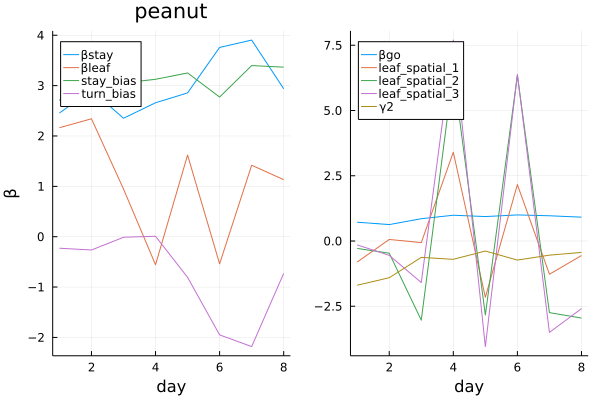

In [13]:
animal = "peanut"
p1 = plot()
for i in 2:5
    plot!(results[animal].x[:, i], label=results[animal].varnames[i], legend=:topleft)
end
title!(animal)
xlabel!("day")
ylabel!("β")

p2 = plot()
plot!(0.5.+0.5.*erf.(results[animal].x[:, 1] ./ sqrt(2)), label=results[animal].varnames[1], legend=:topleft)
for i in 6:9
    plot!(results[animal].x[:, i], label=results[animal].varnames[i], legend=:topleft)
end
# title!("$(animal) (by day)")
xlabel!("day")
plot(p1, p2)

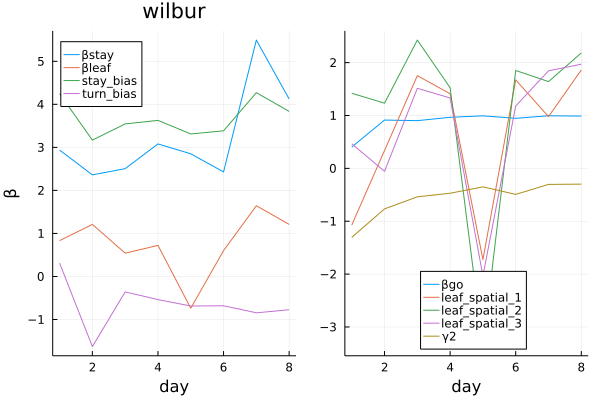

In [14]:
animal = "wilbur"
p1 = plot()
for i in 2:5
    plot!(results[animal].x[:, i], label=results[animal].varnames[i], legend=:topleft)
end
title!(animal)
xlabel!("day")
ylabel!("β")

p2 = plot()
plot!(0.5.+0.5.*erf.(results[animal].x[:, 1] ./ sqrt(2)), label=results[animal].varnames[1], legend=:topleft)
for i in 6:9
    plot!(results[animal].x[:, i], label=results[animal].varnames[i], legend=:topleft)
end
plot!(legend=(0.4, 0.22))
# title!("$(animal) (by day)")
xlabel!("day")
plot(p1, p2)

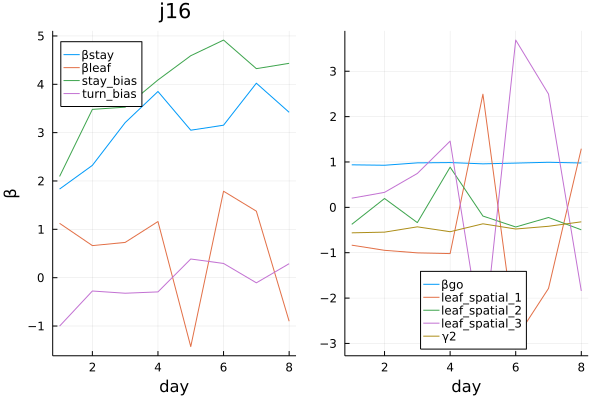

In [15]:
animal = "j16"
p1 = plot()
for i in 2:5
    plot!(results[animal].x[:, i], label=results[animal].varnames[i], legend=:topleft)
end
title!(animal)
xlabel!("day")
ylabel!("β")

p2 = plot()
plot!(0.5.+0.5.*erf.(results[animal].x[:, 1] ./ sqrt(2)), label=results[animal].varnames[1], legend=:topleft)
for i in 6:9
    plot!(results[animal].x[:, i], label=results[animal].varnames[i], legend=:topleft)
end
plot!(legend=(0.4, 0.22))
# title!("$(animal) (by day)")
xlabel!("day")
plot(p1, p2)

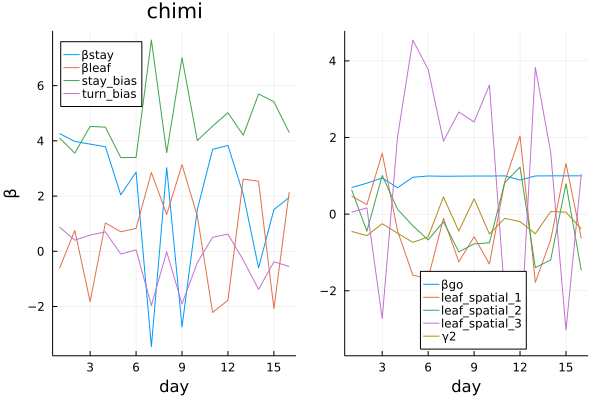

In [16]:
animal = "chimi"
p1 = plot()
for i in 2:5
    plot!(results[animal].x[:, i], label=results[animal].varnames[i], legend=:topleft)
end
title!(animal)
xlabel!("day")
ylabel!("β")

p2 = plot()
plot!(0.5.+0.5.*erf.(results[animal].x[:, 1] ./ sqrt(2)), label=results[animal].varnames[1], legend=:topleft)
for i in 6:9
    plot!(results[animal].x[:, i], label=results[animal].varnames[i], legend=:topleft)
end
plot!(legend=(0.4, 0.22))
# title!("$(animal) (by day)")
xlabel!("day")
plot(p1, p2)

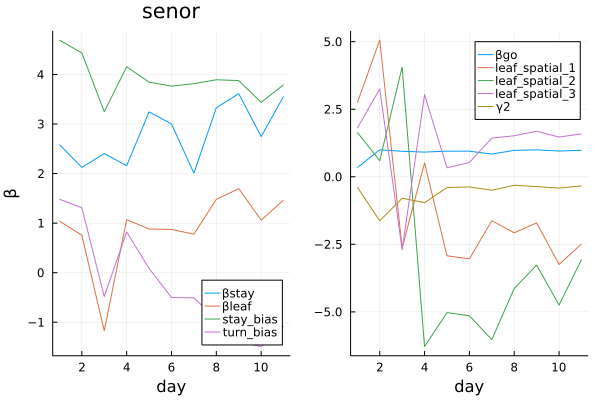

In [17]:
animal = "senor"
p1 = plot()
for i in 2:5
    plot!(results[animal].x[:, i], label=results[animal].varnames[i], legend=:topleft)
end
plot!(legend=:bottomright)
title!(animal)
xlabel!("day")
ylabel!("β")

p2 = plot()
plot!(0.5.+0.5.*erf.(results[animal].x[:, 1] ./ sqrt(2)), label=results[animal].varnames[1], legend=:topleft)
for i in 6:9
    plot!(results[animal].x[:, i], label=results[animal].varnames[i], legend=:topleft)
end
plot!(legend=:topright)
# title!("$(animal) (by day)")
xlabel!("day")
plot(p1, p2)